In [1]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_DIR = Path("../data/raw/gaussian_filtered_images")

print(DATA_DIR.exists())

True


In [3]:
classes = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print(classes)

['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [4]:
class_counts = {}

for class_name in classes:
    class_dir = DATA_DIR / class_name
    class_counts[class_name] = len(list(class_dir.glob("*")))

class_counts

{'Mild': 370,
 'Moderate': 999,
 'No_DR': 1805,
 'Proliferate_DR': 295,
 'Severe': 193}

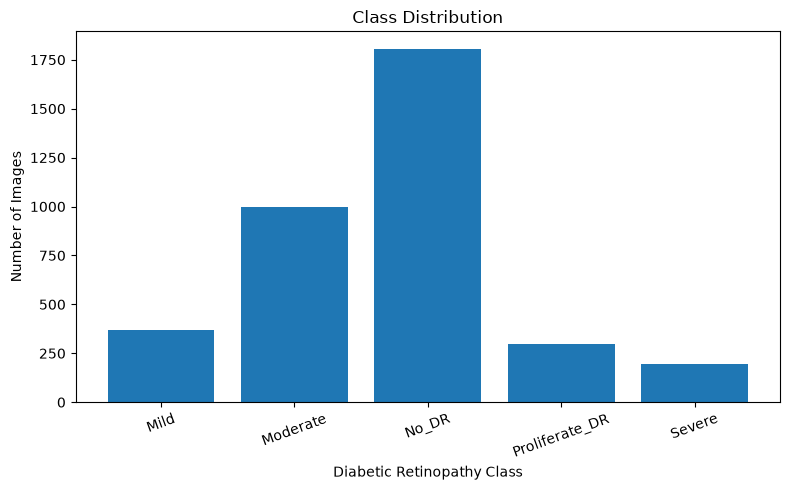

In [5]:
plt.figure(figsize=(8, 5))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Diabetic Retinopathy Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

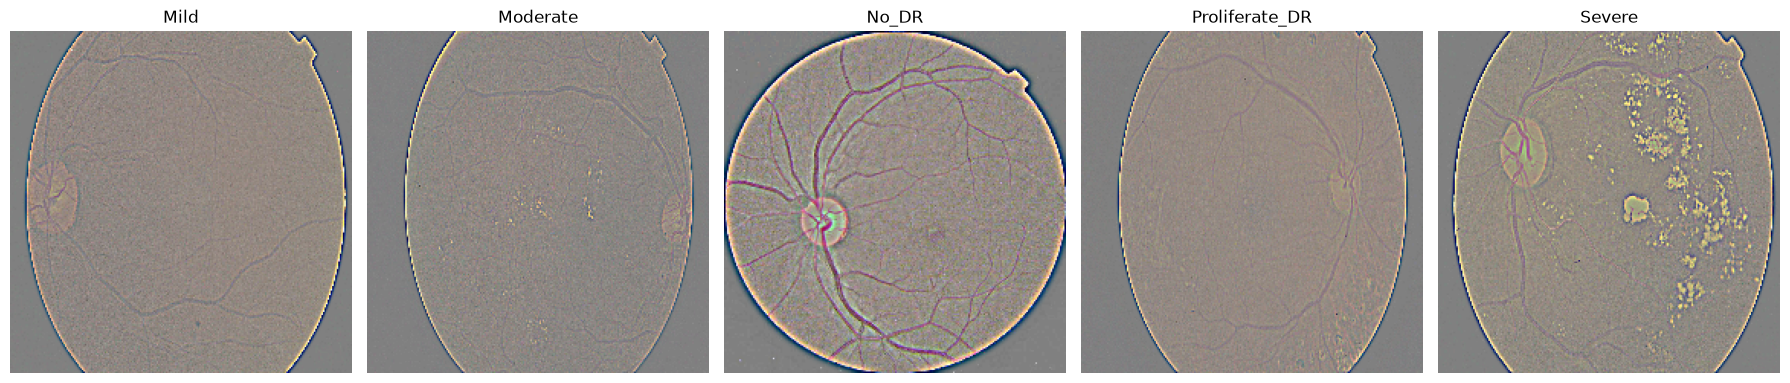

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, class_name in zip(axes, classes):
    class_dir = DATA_DIR / class_name
    image_path = next(class_dir.glob("*"))

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
image_info = []

for class_name in classes:
    class_dir = DATA_DIR / class_name

    # Take the first image from each class
    image_path = next(class_dir.glob("*"))

    with Image.open(image_path) as image:
        image_info.append({
            "class": class_name,
            "filename": image_path.name,
            "size": image.size,
            "mode": image.mode,
            "format": image.format
        })

pd.DataFrame(image_info)

,class,filename,size,mode,format
0,Mild,0024cdab0c1e.png,"(224, 224)",RGB,PNG
1,Moderate,000c1434d8d7.png,"(224, 224)",RGB,PNG
2,No_DR,002c21358ce6.png,"(224, 224)",RGB,PNG
3,Proliferate_DR,001639a390f0.png,"(224, 224)",RGB,PNG
4,Severe,0104b032c141.png,"(224, 224)",RGB,PNG


In [8]:
label_map = {
    "No_DR": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "Proliferate_DR": 4
}

In [9]:
data = []

for class_name, label in label_map.items():
    class_dir = DATA_DIR / class_name

    for image_path in class_dir.glob("*"):
        data.append({
            "image_path": str(image_path),
            "label": label,
            "class_name": class_name
        })

df = pd.DataFrame(data)

print("Total images:", len(df))
df.head()

Total images: 3662


,image_path,label,class_name
0,..\data\raw\gaussian_filtered_images\No_DR\002...,0,No_DR
1,..\data\raw\gaussian_filtered_images\No_DR\005...,0,No_DR
2,..\data\raw\gaussian_filtered_images\No_DR\009...,0,No_DR
3,..\data\raw\gaussian_filtered_images\No_DR\00c...,0,No_DR
4,..\data\raw\gaussian_filtered_images\No_DR\00f...,0,No_DR


In [10]:
print(df["label"].value_counts().sort_index())

label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [11]:
print("Missing files:", (~df["image_path"].map(lambda x: Path(x).exists())).sum())

Missing files: 0


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

In [14]:
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 2929
Validation samples: 733


In [15]:
print("Training distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts(normalize=True).sort_index())

Training distribution:
label
0    0.493001
1    0.101058
2    0.272789
3    0.052578
4    0.080574
Name: proportion, dtype: float64

Validation distribution:
label
0    0.492497
1    0.100955
2    0.272851
3    0.053206
4    0.080491
Name: proportion, dtype: float64


In [16]:
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 2929
Validation samples: 733


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader

In [21]:
from transformers import AutoImageProcessor

c:\Users\imman\OneDrive\Desktop\FineTuning_vit_DR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
MODEL_NAME = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

In [23]:
class DiabeticRetinopathyDataset(Dataset):

    def __init__(self, dataframe, processor):
        self.dataframe = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["image_path"]).convert("RGB")

        inputs = self.processor(
            images=image,
            return_tensors="pt"
        )

        inputs = {key: value.squeeze(0) for key, value in inputs.items()}

        inputs["labels"] = torch.tensor(row["label"], dtype=torch.long)

        return inputs

In [25]:
train_dataset = DiabeticRetinopathyDataset(
    train_df,
    processor
)

val_dataset = DiabeticRetinopathyDataset(
    val_df,
    processor
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 2929
Validation dataset: 733


In [26]:
sample = train_dataset[0]

print("Keys:", sample.keys())
print("Pixel values shape:", sample["pixel_values"].shape)
print("Label:", sample["labels"])

Keys: dict_keys(['pixel_values', 'labels'])
Pixel values shape: torch.Size([3, 224, 224])
Label: tensor(0)


In [27]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [28]:
batch = next(iter(train_loader))

print("Pixel values shape:", batch["pixel_values"].shape)
print("Labels shape:", batch["labels"].shape)
print("Labels:", batch["labels"])

Pixel values shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([0, 2, 4, 0, 0, 0, 4, 2, 2, 4, 2, 0, 2, 0, 0, 0])


In [29]:
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))

Number of training batches: 184
Number of validation batches: 46


In [30]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 2699.49it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [31]:
print(model.classifier)

Linear(in_features=768, out_features=5, bias=True)


In [32]:
print(model.config.num_labels)

5


In [33]:
outputs = model(
    pixel_values=batch["pixel_values"],
    labels=batch["labels"]
)

print("Logits shape:", outputs.logits.shape)
print("Loss:", outputs.loss.item())

Logits shape: torch.Size([16, 5])
Loss: 1.4842065572738647


In [34]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False
